### Carga de imágenes y etiquetas
Se recorren todas las carpetas dentro de `images`.  
Cada carpeta representa una clase de comida.  
Se asigna un número a cada clase, se redimensionan las imágenes a 32x32, se convierten a RGB,  
Se guardan las imágenes en `X` y las etiquetas numéricas en `y`.

In [36]:
import os
import cv2
import numpy as np

DATA_ROOT = "images"          
IMG_SIZE =32

X = []
y = []

# Obtener las clases (nombres de carpetas) ordenadas
clases = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
class_to_idx = {nombre: idx for idx, nombre in enumerate(clases)}

print("Número de clases:", len(clases))

for clase in clases:
    carpeta = os.path.join(DATA_ROOT, clase)
    label = class_to_idx[clase]          
    
    for file in os.listdir(carpeta):
        path = os.path.join(carpeta, file)
        img = cv2.imread(path)
        
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.flatten()
            
            X.append(img)
            y.append(label)

X = np.array(X)
y = np.array(y)
print("Shape X:", X.shape)
print("Shape y:", y.shape)
num_labels = len(clases)
print("Número de clases:", num_labels)
print(y)

Número de clases: 101
Shape X: (101000, 3072)
Shape y: (101000,)
Número de clases: 101
[  0   0   0 ... 100 100 100]


Se convierten las listas a arrays de NumPy.  
Luego se mezclan aleatoriamente las imágenes y las etiquetas juntas para evitar que el orden de las clases afecte el entrenamiento.

In [37]:

np.random.seed(42)
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Ejemplo de y mezclado:", y[:15])

Shape X: (101000, 3072)
Shape y: (101000,)
Ejemplo de y mezclado: [92 52 45 24 41 29 68 50 50 27 42 75 46 82 69]


In [38]:

print(X.nbytes)
print(X.nbytes / (1024**3), "GB")

310272000
0.28896331787109375 GB


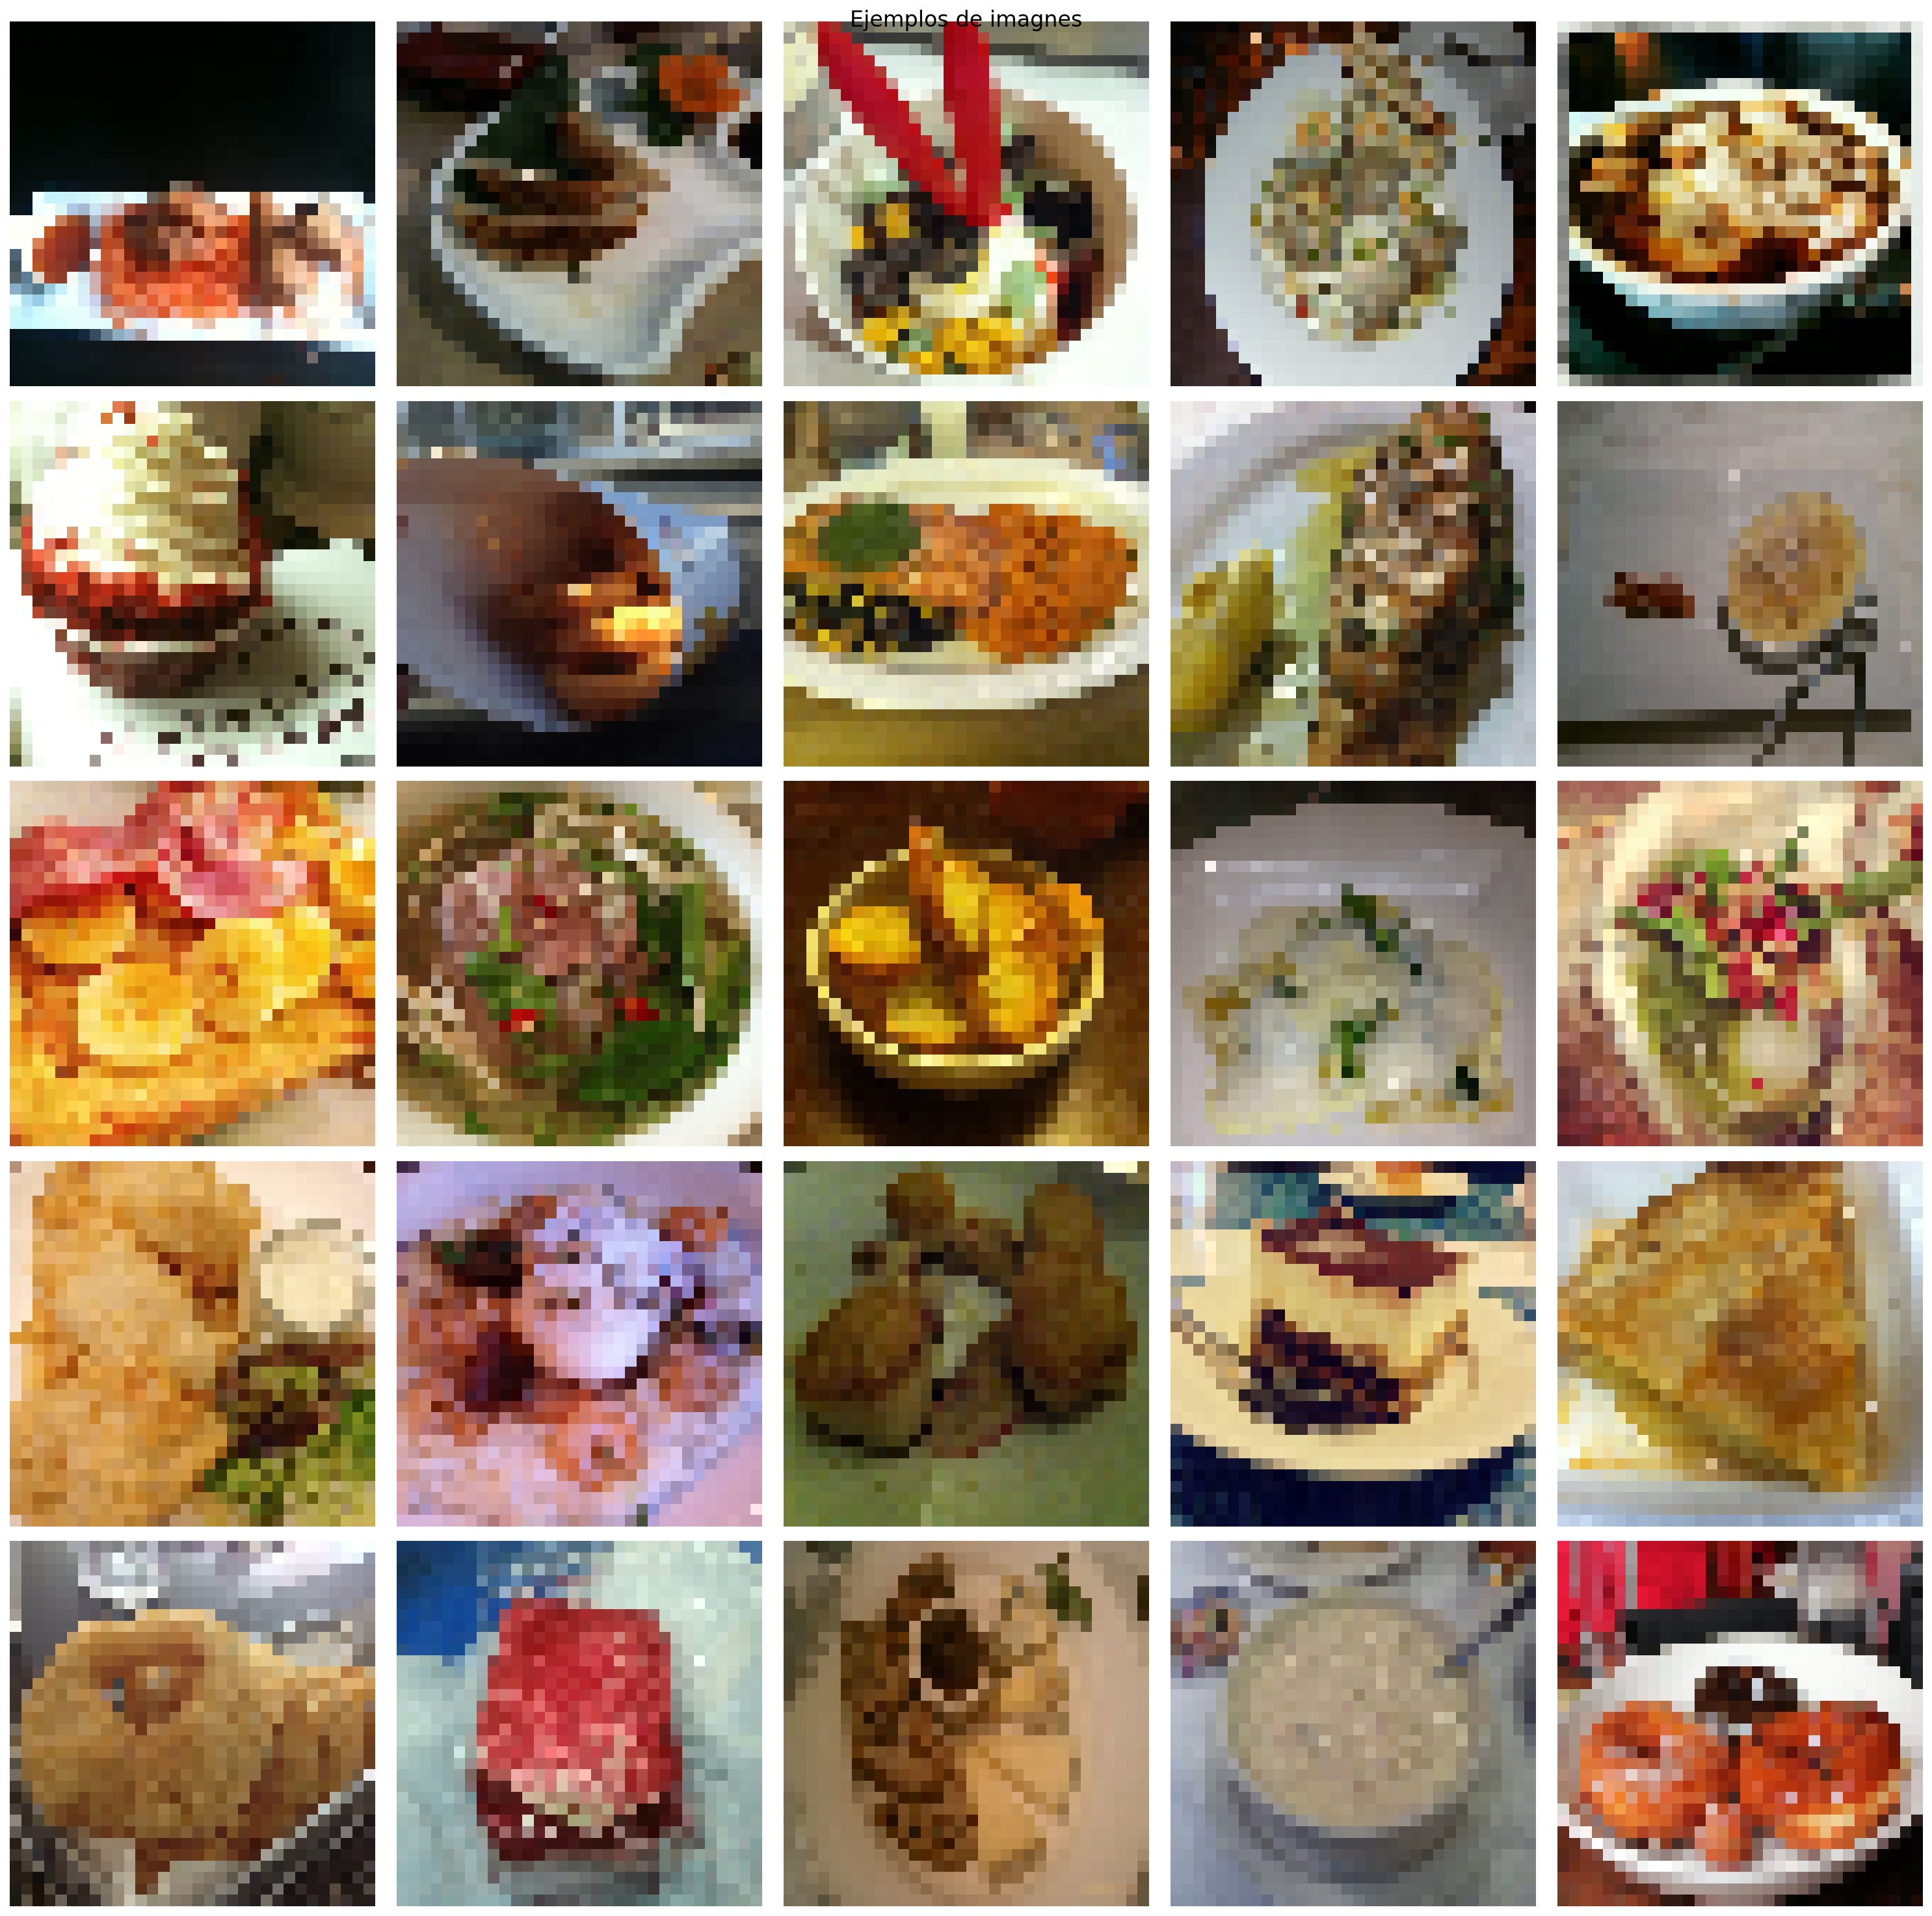

In [39]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(5, 5, figsize=(20, 20), dpi=150)

for i, ax in enumerate(axes.flat):
    img = X[i]

    # reshape a imagen
    img = img.reshape(32, 32, 3)
    img = img.astype(np.float64) / 255.0
    
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Ejemplos de imagnes', fontsize=16)
plt.tight_layout()
plt.show()

División del dataset
Se divide el conjunto de datos en:
- 80% para entrenamiento (`X_train`, `y_train`)
- 20% para prueba (`X_test`, `y_test`)

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)

Forma de X_train: (80800, 3072)
Forma de X_test: (20200, 3072)


se normalizan (dividiendo entre 255) y se aplanan.

In [41]:
X_train=X_train.astype(np.float64)
X_test=X_test.astype(np.float64)
X_train /= 255.0
X_test /= 255.0

In [42]:
print(X_train.nbytes / (1024**3), "GB")
print(X_test.nbytes / (1024**3), "GB")

1.849365234375 GB
0.46234130859375 GB


### Función Sigmoid
Función que convierte cualquier valor en un número entre 0 y 1 (probabilidad).  


In [43]:
def sigmoid(z):
    """
    Calcula la sigmoide de z

    """
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

###  Función de costo (lrCostFunction)
Calcula el costo (error) de la regresión logística con regularización y también el gradiente.  
Esta es la función que el optimizador intentará minimizar durante el entrenamiento.

In [44]:
def lrCostFunction(theta, X, y, lambda_):

    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-15, 1 - 1e-15)
    temp = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # grad = (1 / m) * (h - y).dot(X)
    # grad = grad + (lambda_ / m) * temp

    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

###  Algoritmo One-vs-All
Implementa el enfoque One-vs-All.  
Entrena un clasificador de regresión logística binaria por cada una de las 101 clases.  
Al finalizar se obtiene la matriz `all_theta` con los parámetros de todos los clasificadores.

In [54]:
def OneVsAllOM(X, y, num_labels, lambda_):
  # algunas variables utiles
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))
    
    X = np.concatenate([np.ones((m, 1)), X], axis=1)


    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter':200}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x
        
        porcentaje = ((c + 1) / num_labels) * 100
        print(f"Entrenando clase {c + 1}/{num_labels} → {porcentaje:.2f}%")

    return all_theta

###  Entrenamiento del modelo
Se entrena el modelo completo usando regularización (`lambda_ = 0.03`) y un máximo de 50 iteraciones por cada clase.

In [55]:
from scipy import optimize
lambda_ = 0.03
all_theta = OneVsAllOM(X_train, y_train, num_labels, lambda_)
print(all_theta.shape)

Entrenando clase 1/101 → 0.99%
Entrenando clase 2/101 → 1.98%
Entrenando clase 3/101 → 2.97%
Entrenando clase 4/101 → 3.96%
Entrenando clase 5/101 → 4.95%
Entrenando clase 6/101 → 5.94%
Entrenando clase 7/101 → 6.93%
Entrenando clase 8/101 → 7.92%
Entrenando clase 9/101 → 8.91%
Entrenando clase 10/101 → 9.90%
Entrenando clase 11/101 → 10.89%
Entrenando clase 12/101 → 11.88%
Entrenando clase 13/101 → 12.87%
Entrenando clase 14/101 → 13.86%
Entrenando clase 15/101 → 14.85%
Entrenando clase 16/101 → 15.84%
Entrenando clase 17/101 → 16.83%
Entrenando clase 18/101 → 17.82%
Entrenando clase 19/101 → 18.81%
Entrenando clase 20/101 → 19.80%
Entrenando clase 21/101 → 20.79%
Entrenando clase 22/101 → 21.78%
Entrenando clase 23/101 → 22.77%
Entrenando clase 24/101 → 23.76%
Entrenando clase 25/101 → 24.75%
Entrenando clase 26/101 → 25.74%
Entrenando clase 27/101 → 26.73%
Entrenando clase 28/101 → 27.72%
Entrenando clase 29/101 → 28.71%
Entrenando clase 30/101 → 29.70%
Entrenando clase 31/101 → 30.

In [56]:
print(all_theta)

[[-6.78214613e+00  1.56029727e-02  1.06372343e-01 ...  2.13405373e-01
   3.97720830e-01  2.73791501e-01]
 [-2.53717327e+00  3.38533240e-01 -1.21957673e-03 ...  1.53717670e-01
  -1.92584776e-02 -2.33779971e-01]
 [-7.06566918e+00 -4.47100192e-01  1.50959516e-01 ... -4.76930105e-02
   1.56091784e-01  5.35344413e-02]
 ...
 [-4.88065606e+00 -2.53513028e-02 -1.31059507e-01 ...  1.16170902e-01
   7.27680542e-02 -1.61568532e-01]
 [-4.97284196e+00 -1.89975285e-01 -6.45665410e-02 ... -4.07132228e-02
   3.69591253e-01  2.88199540e-01]
 [-6.05390352e+00 -1.48151219e-01  1.69666246e-02 ... -8.75811293e-02
   8.60660802e-02  2.03795538e-01]]


Predicciones
Se realizan las predicciones tanto en el conjunto de entrenamiento como en el de prueba.  
Se elige la clase con la mayor probabilidad usando `argmax`.

In [57]:
def predictOneVsAll(all_theta, X):

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

###  Evaluación del modelo
Se calcula la precisión (porcentaje de aciertos) en el conjunto de entrenamiento y en el de prueba.

In [58]:
# Prediccion sobre todo el conjunto de entrenamiento
pred = predictOneVsAll(all_theta, X_train)
print("Precision de entrenamiento: {:.2f}%".format(np.mean(pred == y_train) * 100))

Precision de entrenamiento: 29.65%


In [59]:
p= predictOneVsAll(all_theta, X_test)
print("Precision de prueba: {:.2f}%".format(np.mean(p == y_test) * 100))

Precision de prueba: 4.73%


Matriz de Confusión

Se genera la matriz de confusión de 101x101 clases para visualizar en qué clases el modelo acierta más y en cuáles se confunde.

Matriz de Confusión calculada exitosamente.


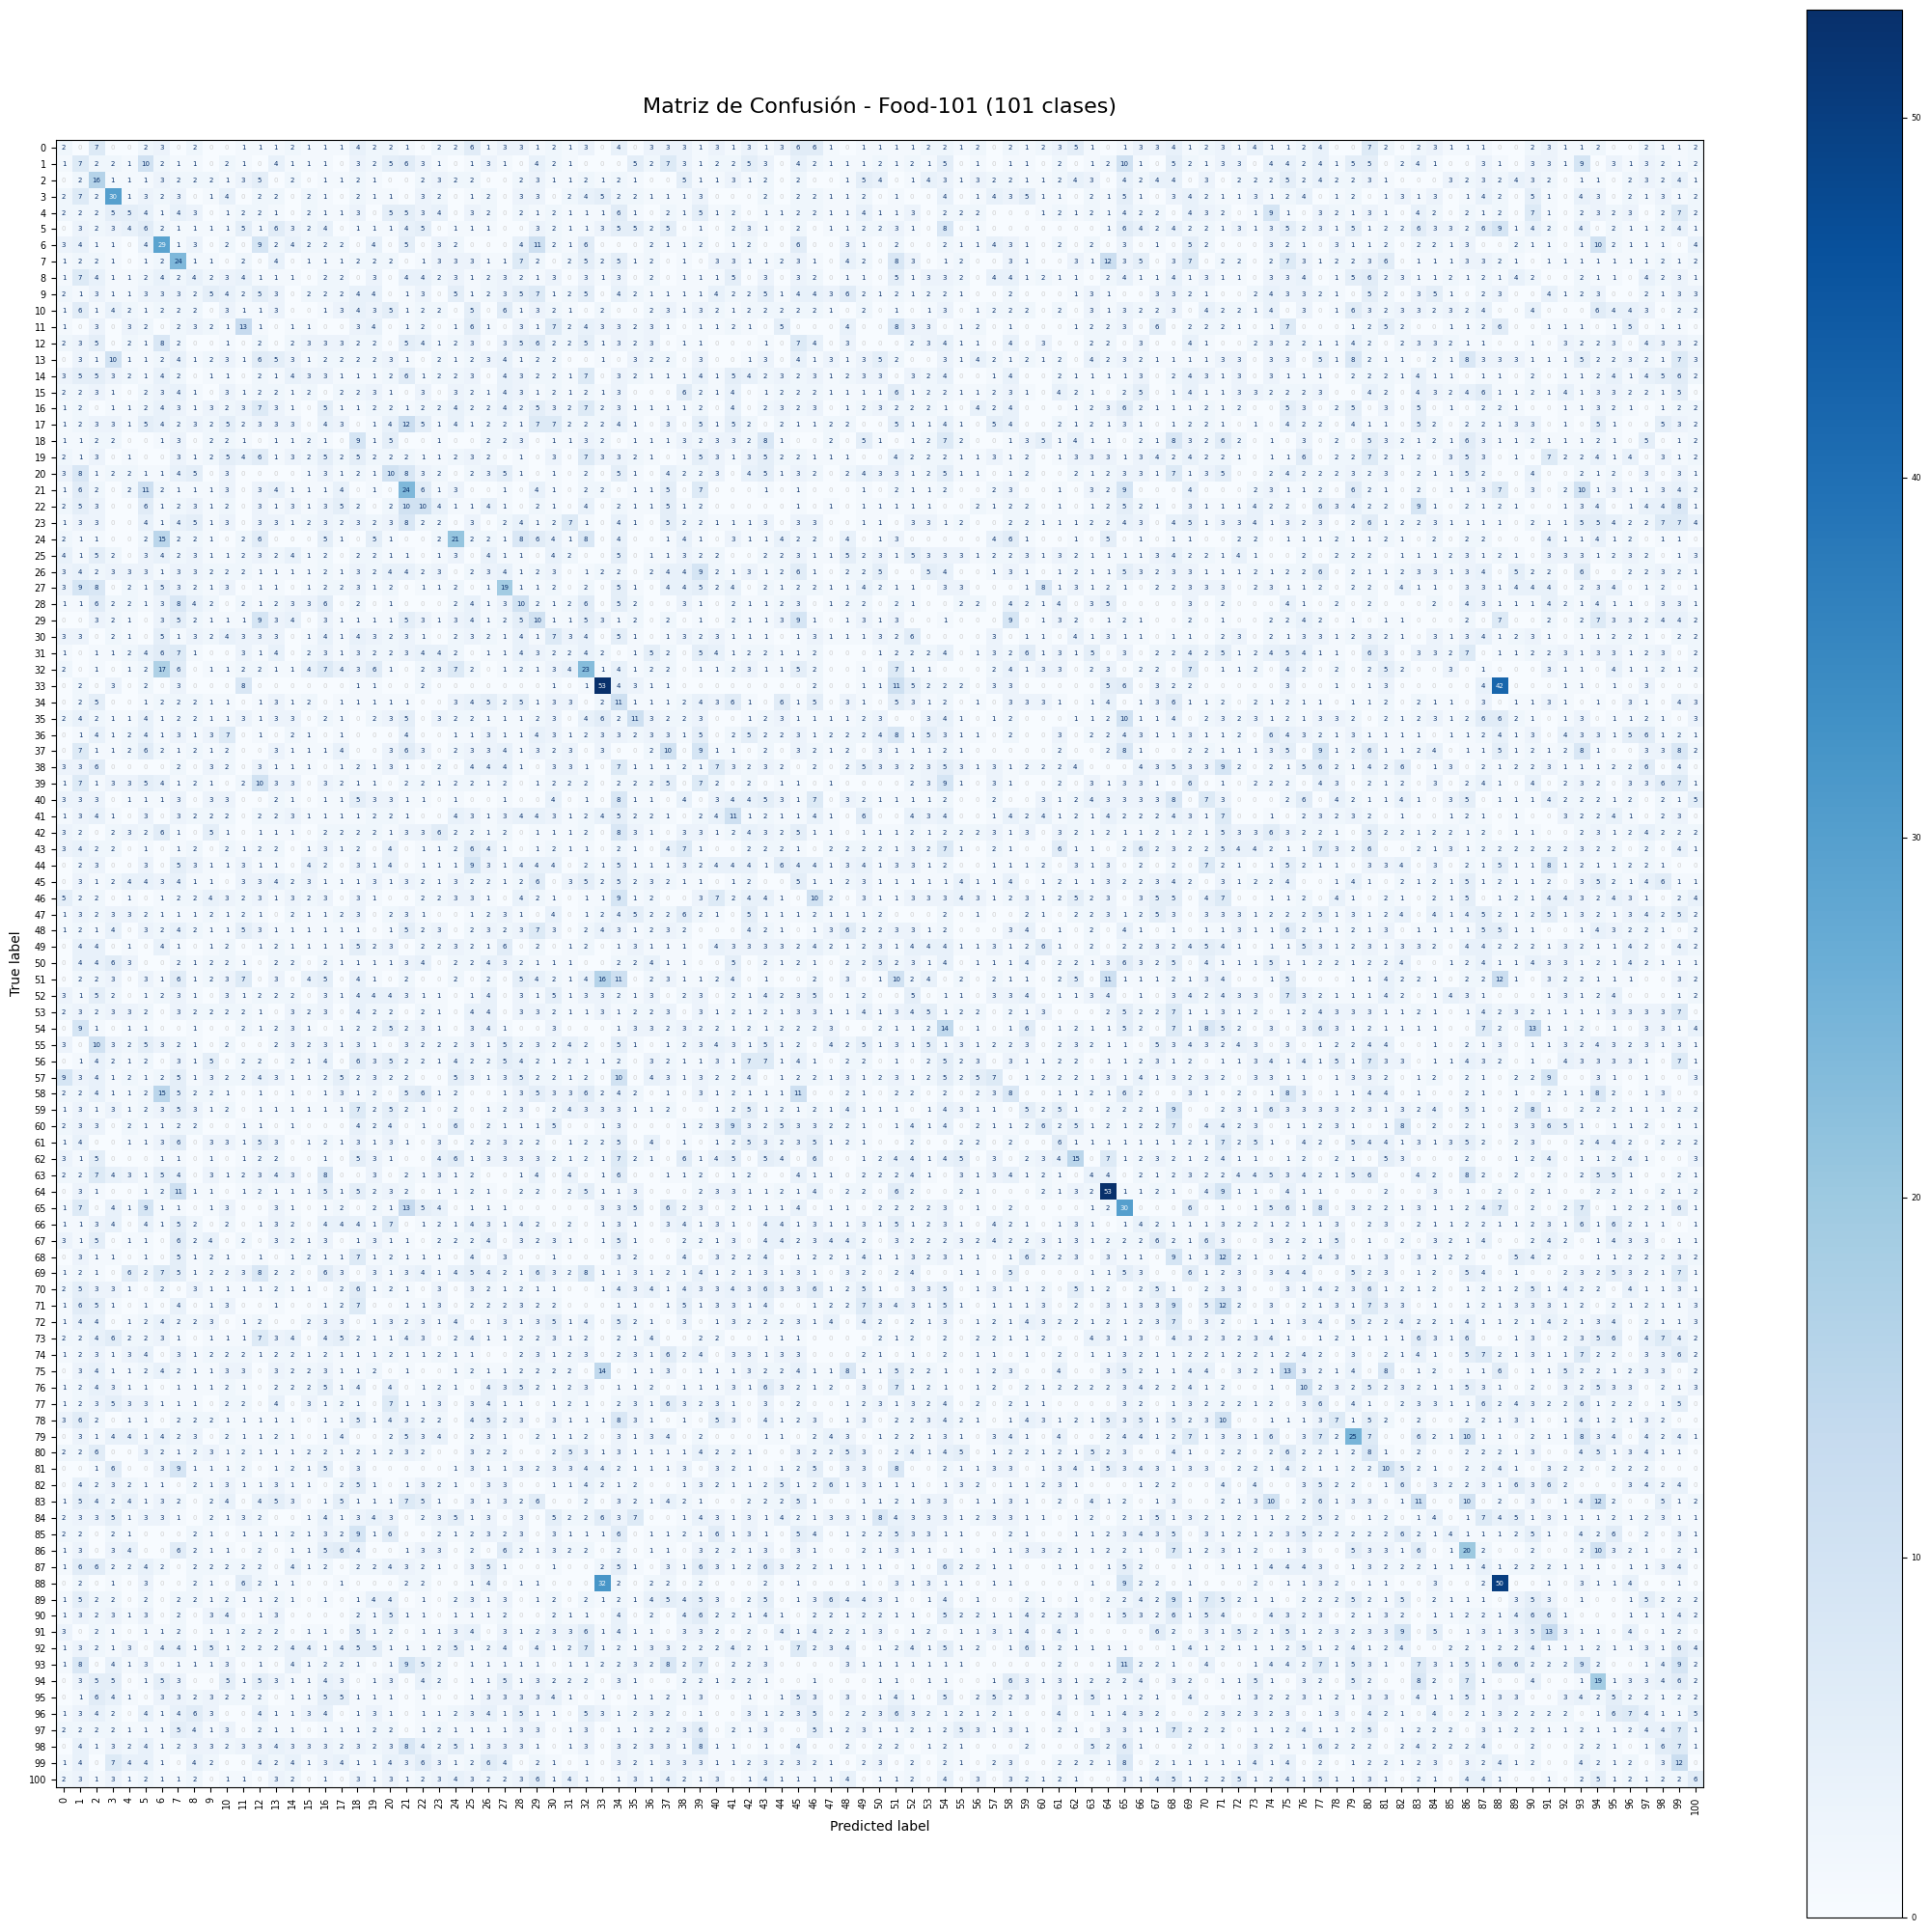

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcular la matriz de confusión
cm = confusion_matrix(y_test, p)
print("Matriz de Confusión calculada exitosamente.")

# 2. Nombres de las clases
clases_unicas = np.unique(y_test)
nombres_clases = [f"{int(c)}" for c in clases_unicas]

# 3. Crear figura grande
fig, ax = plt.subplots(figsize=(22, 20), dpi=100)

plt.rcParams.update({'font.size': 6})

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nombres_clases
)

disp.plot(
    ax=ax,
    cmap=plt.cm.Blues,
    xticks_rotation=90,
    values_format='d'
)

# Números más pequeños
for text in disp.text_.ravel():
    text.set_fontsize(5)
    if text.get_text() == '0':
        text.set_color('#d0d0d0')

ax.set_xticks(np.arange(len(nombres_clases)))
ax.set_yticks(np.arange(len(nombres_clases)))
ax.set_xticklabels(nombres_clases, rotation=90, fontsize=7)
ax.set_yticklabels(nombres_clases, fontsize=7)

plt.title("Matriz de Confusión - Food-101 (101 clases)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Conclusión

En este laboratorio se realizó la clasificación multiclase utilizando el dataset Food-101. Primero se cargaron las imágenes correspondientes a las diferentes clases y se realizó la división de los datos en un conjunto de entrenamiento y otro de prueba. Posteriormente, las imágenes fueron redimensionadas y normalizadas para poder utilizarlas en el proceso de clasificación.

Se aplicó el método de Regresión Logística One-vs-All, donde se entrena un clasificador para cada una de las clases del dataset. Finalmente, se realizaron las predicciones sobre el conjunto de prueba y se evaluó el rendimiento del modelo mediante la precisión y la matriz de confusión.